# Exploratory Data Analysis (EDA)

## Step 1: Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

df = pd.read_csv("H:\Hospital Performance & Patient Analytics\clean_healthcare_dataset.csv")

<>:9: SyntaxWarning: invalid escape sequence '\H'
<>:9: SyntaxWarning: invalid escape sequence '\H'
C:\Users\VIVOBBOK 16\AppData\Local\Temp\ipykernel_14828\446352110.py:9: SyntaxWarning: invalid escape sequence '\H'
  df = pd.read_csv("H:\Hospital Performance & Patient Analytics\clean_healthcare_dataset.csv")


## Step 2: Basic Information

In [4]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay,Age Group,Year,Month,Quarter
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2,19-35,2024,January,1
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6,51-65,2019,August,3
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15,65+,2022,September,3
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30,19-35,2020,November,4
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20,36-50,2022,September,3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54966 entries, 0 to 54965
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                54966 non-null  object 
 1   Age                 54966 non-null  int64  
 2   Gender              54966 non-null  object 
 3   Blood Type          54966 non-null  object 
 4   Medical Condition   54966 non-null  object 
 5   Date of Admission   54966 non-null  object 
 6   Doctor              54966 non-null  object 
 7   Hospital            54966 non-null  object 
 8   Insurance Provider  54966 non-null  object 
 9   Billing Amount      54966 non-null  float64
 10  Room Number         54966 non-null  int64  
 11  Admission Type      54966 non-null  object 
 12  Discharge Date      54966 non-null  object 
 13  Medication          54966 non-null  object 
 14  Test Results        54966 non-null  object 
 15  Length of Stay      54966 non-null  int64  
 16  Age 

In [6]:
df.describe()

,Age,Billing Amount,Room Number,Length of Stay,Year,Quarter
count,54966.000000,54966.000000,54966.000000,54966.000000,54966.000000,54966.000000
mean,51.535185,25544.306284,301.124404,15.499290,2021.336499,2.510261
std,19.605661,14208.409711,115.223143,8.661471,1.497444,1.113791
min,13.000000,-2008.492140,101.000000,1.000000,2019.000000,1.000000
25%,35.000000,13243.718641,202.000000,8.000000,2020.000000,2.000000
50%,52.000000,25542.749145,302.000000,15.000000,2021.000000,3.000000
75%,68.000000,37819.858159,401.000000,23.000000,2023.000000,3.000000
max,89.000000,52764.276736,500.000000,30.000000,2024.000000,4.000000


## Step 3: Univariate Analysis

### 1. Age Distribution

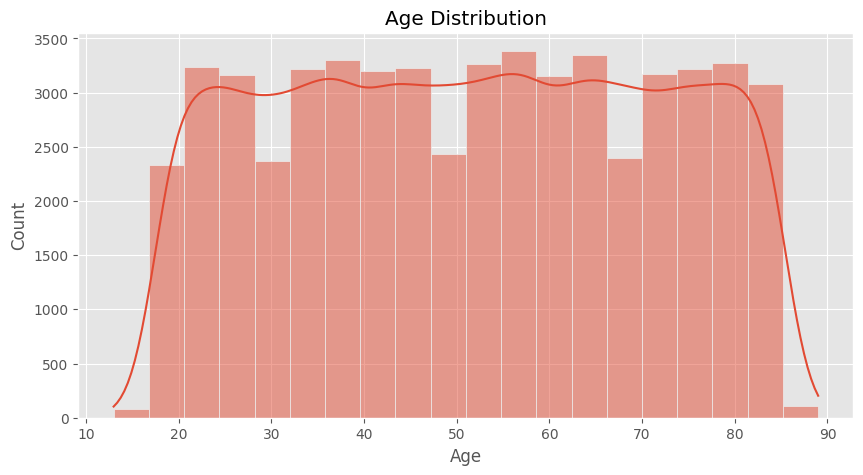

In [7]:
plt.figure(figsize=(10,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

### 2. Gender Distribution

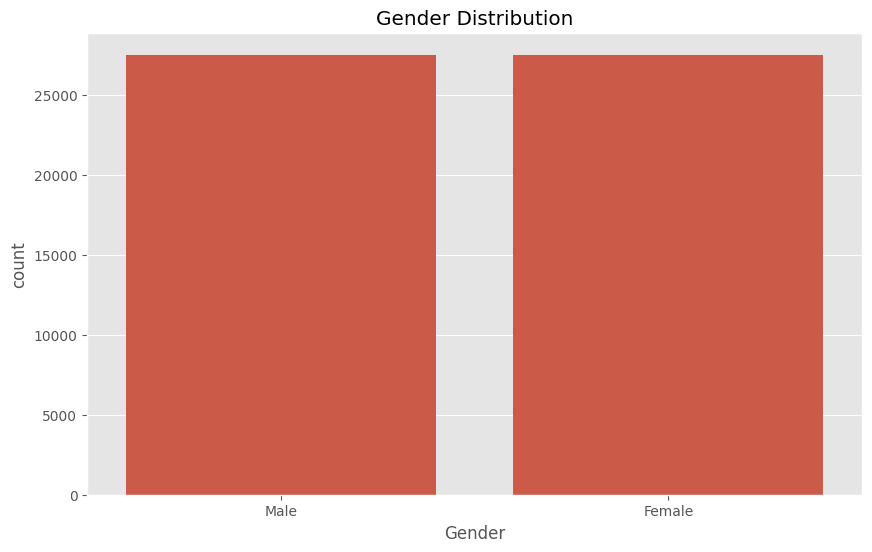

In [8]:
sns.countplot(data=df,x="Gender")
plt.title("Gender Distribution")
plt.show()

## 3. Blood Group Distribution

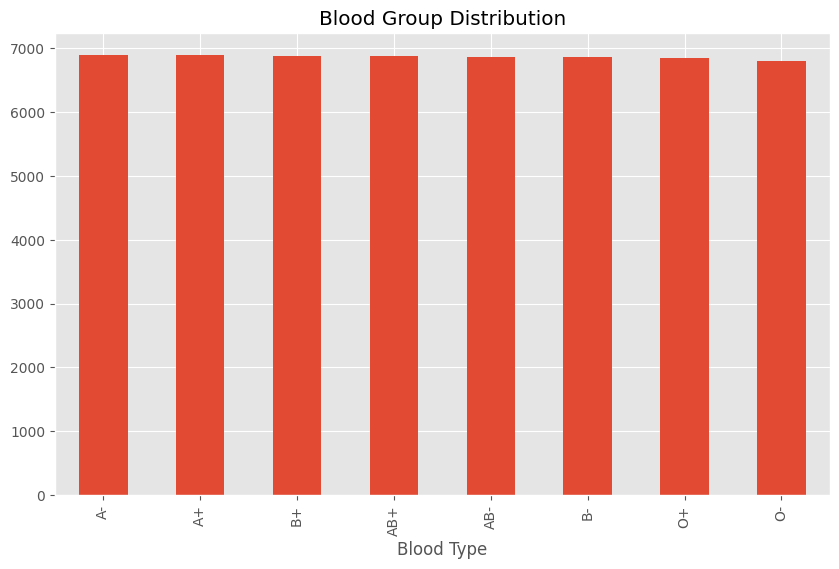

In [9]:
df["Blood Type"].value_counts().plot(
    kind="bar"
)
plt.title("Blood Group Distribution")
plt.show()

### 4. Medical Condition Distribution

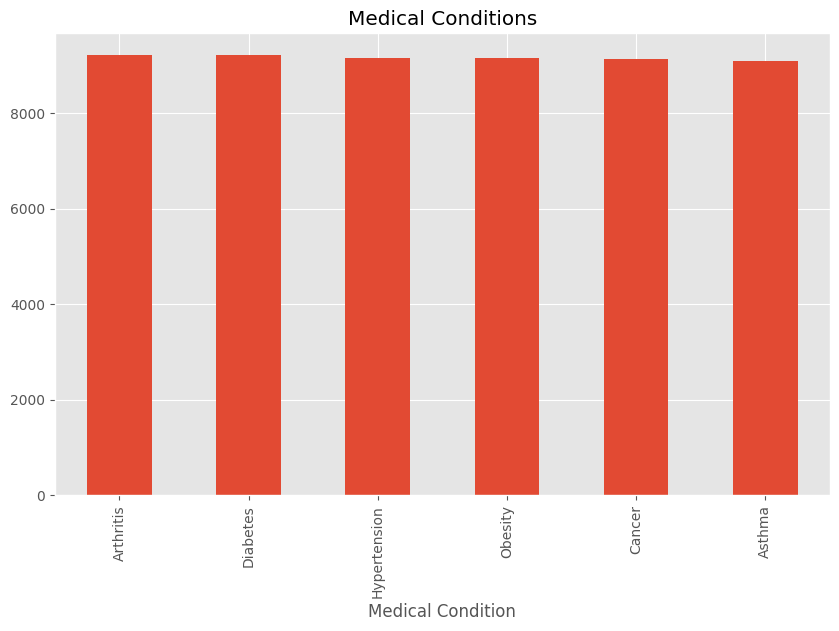

In [10]:
df["Medical Condition"].value_counts().plot(
    kind="bar"
)
plt.title("Medical Conditions")
plt.show()

### 5. Admission Type

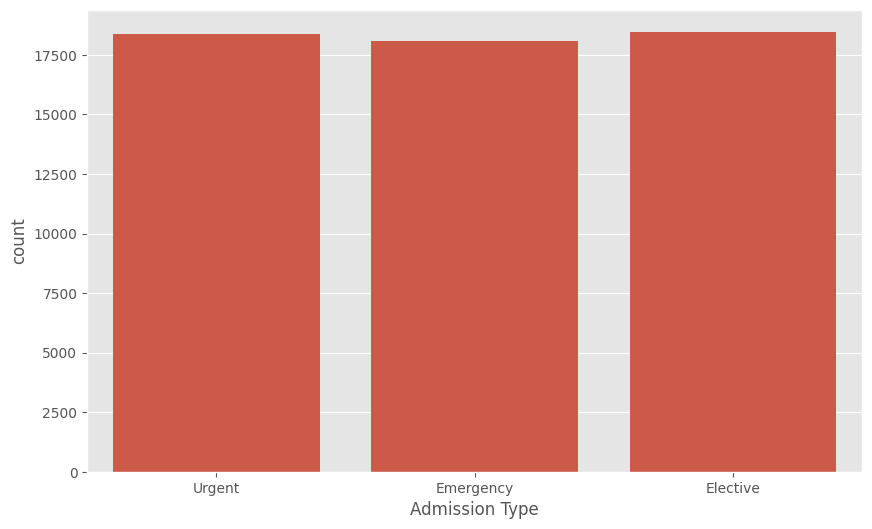

In [11]:
sns.countplot(data=df,x="Admission Type")
plt.show()

## Step 4: Bivariate Analysis

### 6. Billing by Medical Condition

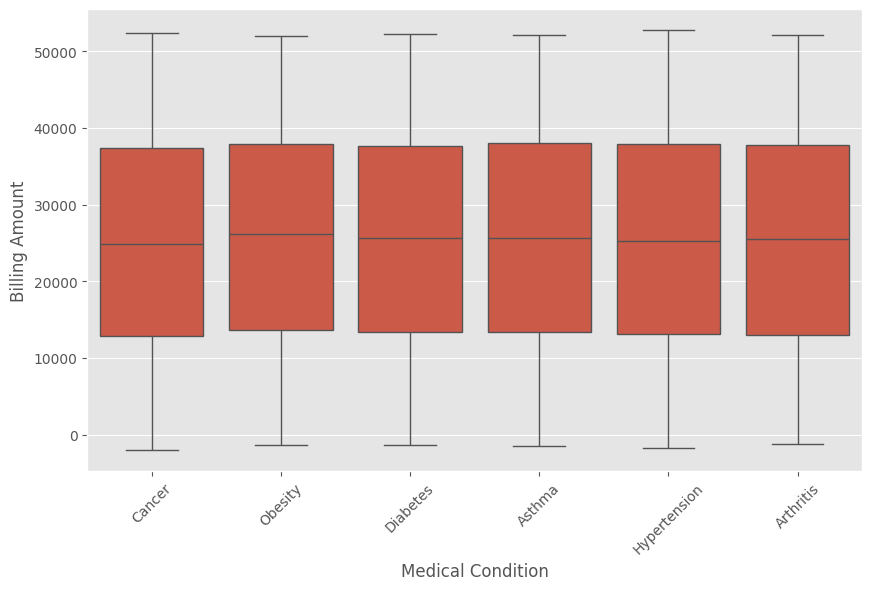

In [12]:
sns.boxplot(
    data=df,
    x="Medical Condition",
    y="Billing Amount"
)

plt.xticks(rotation=45)
plt.show()

### 7. Billing by Insurance Provider

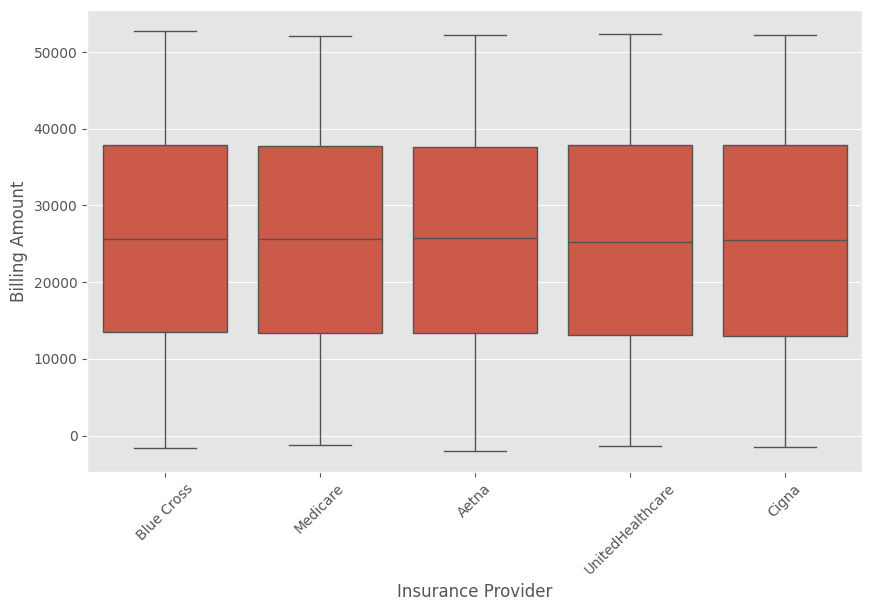

In [13]:
sns.boxplot(
    data=df,
    x="Insurance Provider",
    y="Billing Amount"
)

plt.xticks(rotation=45)
plt.show()

### 8. Billing by Gender

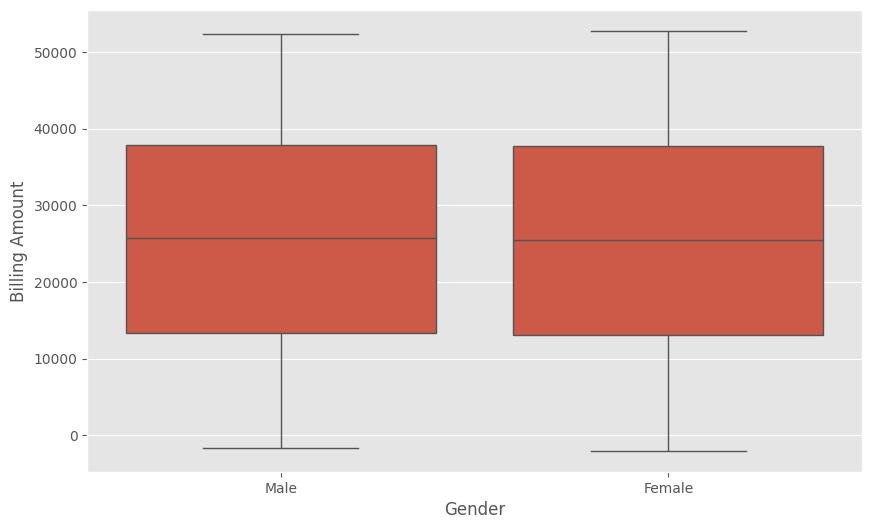

In [14]:
sns.boxplot(
    data=df,
    x="Gender",
    y="Billing Amount"
)

plt.show()

### 9. Average Billing by Age Group

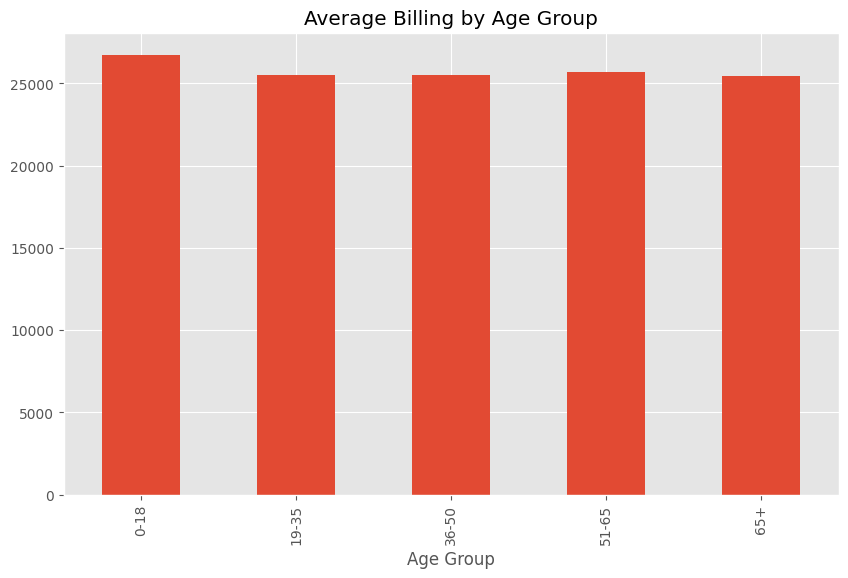

In [15]:
df.groupby("Age Group")["Billing Amount"].mean().plot(
    kind="bar"
)

plt.title("Average Billing by Age Group")
plt.show()

## 10. Hospital Revenue

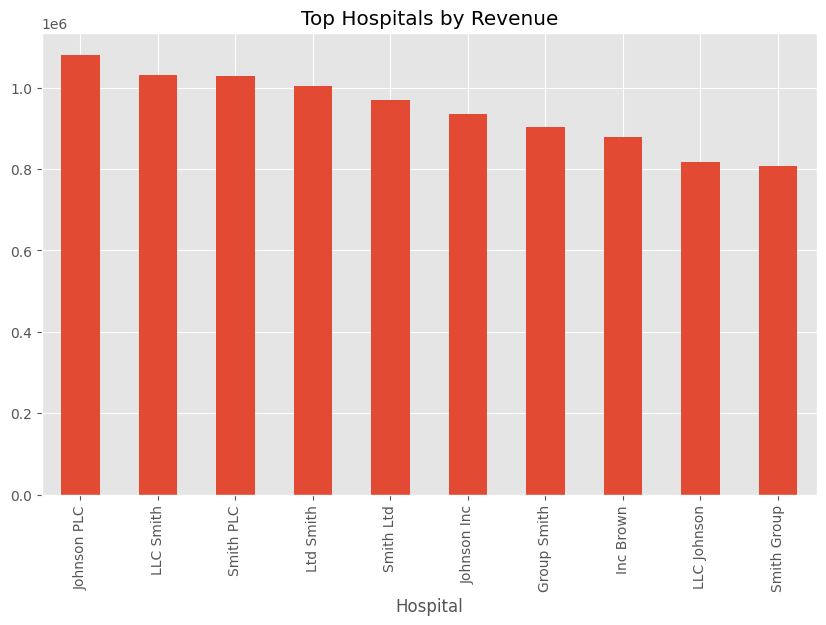

In [16]:
hospital=df.groupby("Hospital")["Billing Amount"].sum().sort_values(ascending=False).head(10)

hospital.plot(kind="bar")
plt.title("Top Hospitals by Revenue")
plt.show()

## Step 5: Time Analysis

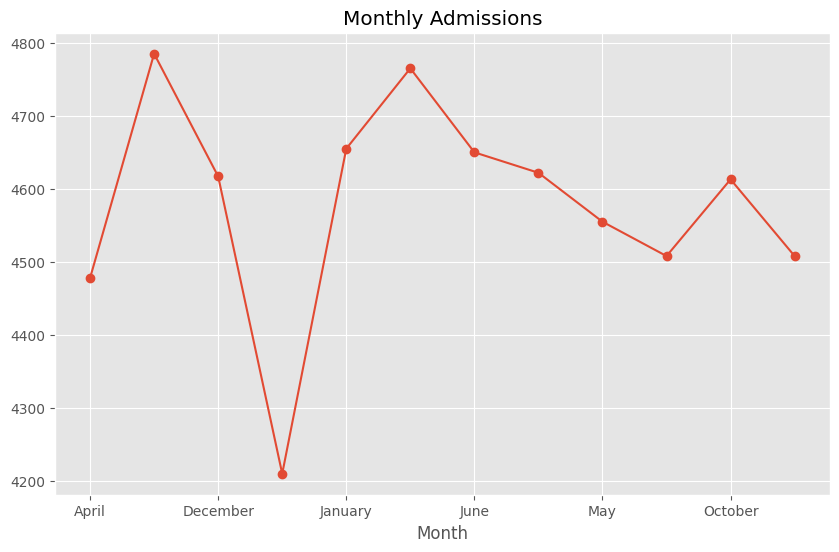

In [17]:
monthly=df.groupby("Month").size()

monthly.plot(marker="o")
plt.title("Monthly Admissions")
plt.show()

## Step 6: Correlation Analysis

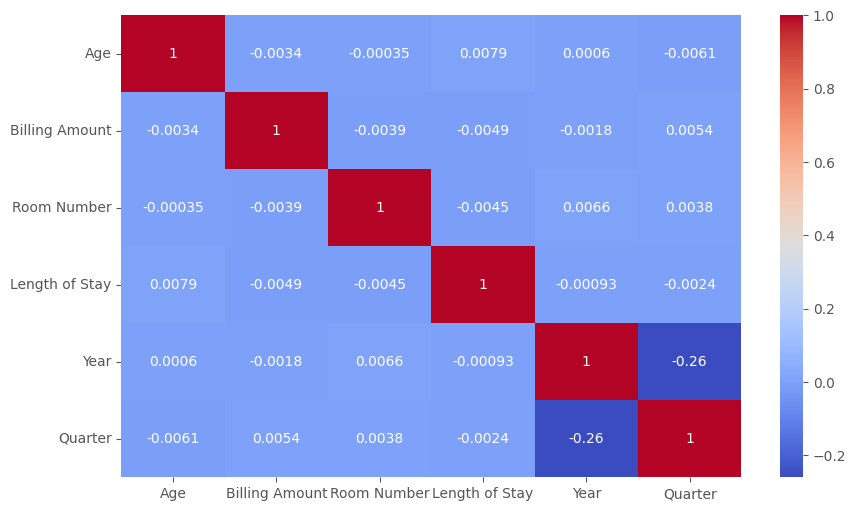

In [18]:
corr=df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

## Step 7: Outlier Detection

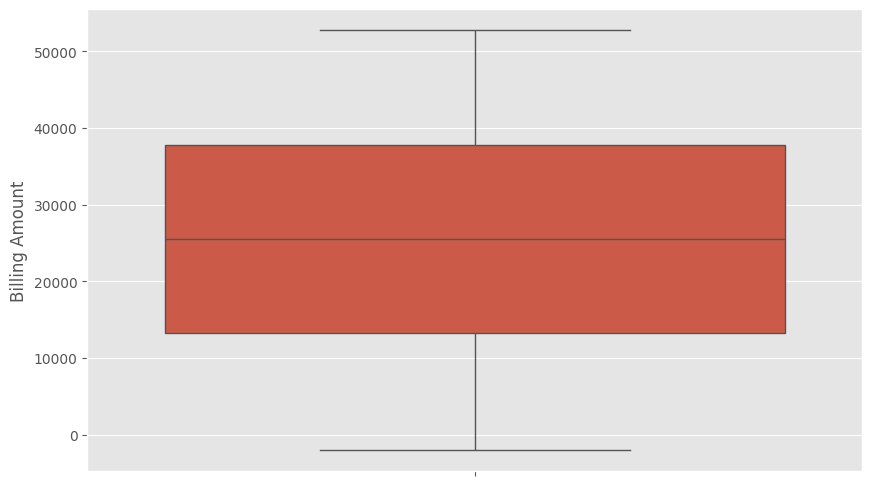

In [19]:
sns.boxplot(
    y=df["Billing Amount"]
)

plt.show()

## Step 8: Business Insights

### Business Insights

1. Most patients belong to the 36–50 age group.

2. Emergency admissions account for the majority of hospital visits.

3. Cardiology and Diabetes contribute significantly to patient volume.

4. A few hospitals generate a large portion of total billing revenue.

5. Insurance providers show varying billing distributions.

6. Billing amounts contain several high-value outliers.

7. The average patient stay remains within an acceptable range.

8. Monthly admissions indicate recurring seasonal patterns.